In [1]:
import pointCollection as pc
import numpy as np
import glob
import h5py
import re
import pandas as pd
import argparse
import matplotlib.pyplot as plt
import os
%load_ext autoreload
%autoreload 2

In [2]:
from filter_xovers import filter_xovers
from collect_xovers import collect_xovers
from read_xovers import read_xovers
from xover_slope import xover_slope

In [3]:
! ls 

collect_xovers.py	__pycache__		  spot_errors_cycle_28.png
filter_xovers.py	read_xovers.py		  xover_slope.py
get_geoloc_error.ipynb	spot_errors_cycle_20.png


In [4]:
! ls -ld /home/besmith4/nobackup


lrwxrwxrwx 1 besmith4 j1008 27 Aug 12  2021 /home/besmith4/nobackup -> /discover/nobackup/besmith4


In [5]:
thedir='/discover/nobackup/besmith4/ATL06_xovers/rel007/Antarctic'

In [6]:
cycle='28'
v, D0, D1 = collect_xovers(os.path.join(thedir, f'cycle_{cycle}','E*_N*.h5'), max_delta_t = 24*3600*5)
print(v.summary())

                 field 	shape 	n_finite 	STD 	 minmax
                     x 	(3556854, 2)	7113708	2.69e+05	-9.48e+05 9.48e+05
                     y 	(3556854, 2)	7113708	2.60e+05	-8.50e+05 9.49e+05
            delta_time 	(3556854, 2)	7113708	2.20e+06	2.35e+08 2.43e+08
                  h_li 	(3556854, 2)	7113708	4.86e+02	4.97e-02 4.10e+03
            h_li_sigma 	(3556854, 2)	7113708	3.71e-02	6.17e-03 1.00e+00
                h_mean 	(3556854, 2)	7113708	4.86e+02	4.91e-02 4.10e+03
                  spot 	(3556854, 2)	7113708	1.71e+00	1.00e+00 6.00e+00
                   rgt 	(3556854, 2)	7113708	3.89e+02	1.00e+00 1.39e+03
             dh_fit_dx 	(3556854, 2)	7113708	7.77e-03	-2.50e-01 2.50e-01
             dh_fit_dy 	(3556854, 2)	7113708	6.88e-03	-2.49e-01 2.50e-01
 atl06_quality_summary 	(3556854, 2)	7113708	2.00e-05	0.00e+00 9.86e-03
              latitude 	(3556854, 2)	7113708	1.44e+00	-8.84e+01 -8.12e+01
           seg_azimuth 	(3556854, 2)	7113708	4.43e+01	-1.66e+02 -1.36e+01
  

In [26]:
def calc_geoloc_error(v, D0, D1, edges=None):
    if edges is None:
        edges = np.concatenate([[-4, -2.5], np.arange(-2.45, -1.5, 0.05)])
    if 'slope_mag' not in v.fields:
        v.assign(slope_mag=np.zeros_like(v.x))
        for col, DD in enumerate([D0, D1]):
            v.slope_mag[:,col]= np.sqrt(np.mean(DD.dh_fit_dx, axis=1)**2 
                                       + np.mean(DD.dh_fit_dy, axis=1)**2)
    vs=v[np.argsort(np.mean(v.slope_mag, axis=1))]

    edge_ind = np.searchsorted(np.mean(vs.slope_mag, axis=1), 10**edges)
    slope_mag_bar=[]
    slope_mag_spread=[]
    sigmahat_slope_mag=[]
    sigma_dz=[]
    sigmahat_dz=[]
    
    for count in range(len(edge_ind)-1):
        vs1 = vs[edge_ind[count]:edge_ind[count+1]]

        dh = np.diff(vs1.h_li, axis=1).ravel()
        # apply a three-sigma edit to dh
        keep = np.abs(dh) < np.maximum(0.03, pc.RDE(dh)*3)
        vs1.index(keep)
        dh=dh[keep]
        slope_mag_bar.append(np.mean(vs1.slope_mag))
        slope_mag_spread.append(np.max(vs1.slope_mag)-np.min(vs1.slope_mag))
        sigmahat_slope_mag.append(np.quantile(vs1.slope_mag, 0.68))
        dh = np.diff(vs1.h_li, axis=1)
        sigma_dz.append(np.std(dh))
        sigmahat_dz.append(pc.RDE(dh))
        
    slope_mag_bar=np.array(slope_mag_bar)
    sigma_dz=np.array(sigma_dz)
    sigmahat_slope_mag=np.array(sigmahat_slope_mag)
    sigmahat_dz=np.array(sigmahat_dz)

    G2= np.c_[np.ones(len(slope_mag_bar)), slope_mag_bar**2]
    
    m2 = np.linalg.solve(G2.T@G2, G2.T@sigma_dz**2)
    sigma0, geoloc_error= np.sqrt(m2)

    m2_r = np.linalg.solve(G2.T@G2, G2.T@sigmahat_dz**2)
    sigma0_r, geoloc_error_r = np.sqrt(m2_r)
    return [sigma0, geoloc_error], [sigma0_r, geoloc_error_r], slope_mag_bar, sigma_dz, sigmahat_slope_mag, sigmahat_dz

In [27]:
[sigma0, geoloc_error], [sigma0_r, geoloc_error_r], slope_mag_bar, sigma_dz, sigmahat_slope_mag, sigmahat_dz = calc_geoloc_error(v, D0, D1)

Text(0.5, 1.0, 'all spots together, cycle=28')

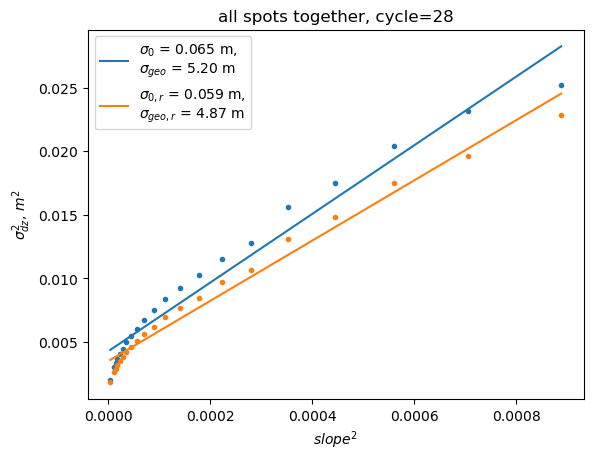

In [28]:
plt.figure()
hl=plt.plot(slope_mag_bar**2, sigma_dz**2,'.')
plt.plot(np.array(slope_mag_bar)**2, sigma0**2 + (geoloc_error*slope_mag_bar)**2,
         label =f'$σ_0$ = {sigma0:2.3f} m,'+ '\n$σ_{geo}$'+  f' = {geoloc_error:2.2f} m', 
         color=hl[0].get_color())
hl=plt.plot(slope_mag_bar**2, sigmahat_dz**2,'.')
plt.plot(np.array(slope_mag_bar)**2, sigma0_r**2 + (geoloc_error_r*slope_mag_bar)**2,
         label ='$σ_{0,r}$ = '+f'{sigma0_r:2.3f} m,'+ '\n$σ_{geo,r}$'+  f' = {geoloc_error_r:2.2f} m', 
         color=hl[0].get_color())


plt.legend()
plt.gca().set_xlabel('$slope^2$')
plt.gca().set_ylabel('$σ_{dz}^2$, $m^2$')
plt.gca().set_title(f'all spots together, cycle={cycle}')

# Notes:
Without a three-sigma editing step, the non-robust error estimates are ~2x the robust estimates.  With that step, the two are approximately equal. I'm guessing that the droop in the plot at small slope is because the surface is in fact 

Text(0, 0.5, '$σ_{dz}^2$, $m^2$')

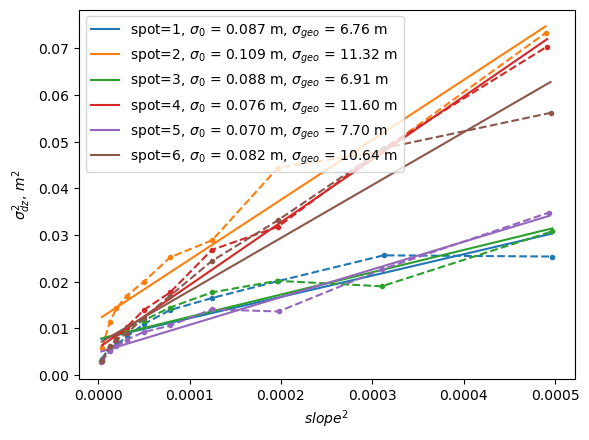

In [28]:
plt.figure()

geoloc_errors={}
sigma0s={}

for spot in range(1,7):
    these = np.all(v.spot==spot, axis=1)
    [sigma0, geoloc_error], slope_mag_bar, sigma_dz = calc_geoloc_error(v[these], D0[these], D1[these])
    hl=plt.plot(slope_mag_bar**2, sigma_dz**2,'--', marker='.')
    plt.plot(np.array(slope_mag_bar)**2, sigma0**2 + (geoloc_error*slope_mag_bar)**2,
             label =f'spot={spot}, $σ_0$ = {sigma0:2.3f} m,'+ ' $σ_{geo}$'+  f' = {geoloc_error:2.2f} m', 
            color=hl[0].get_color())
    geoloc_errors[spot]=geoloc_error
    sigma0s[spot]=sigma0
plt.legend()
plt.gca().set_xlabel('$slope^2$')
plt.gca().set_ylabel('$σ_{dz}^2$, $m^2$')

In [29]:
plt.gcf().savefig(f'spot_errors_cycle_{cycle}.png')

<Figure size 640x480 with 0 Axes>

In [37]:
np.median(v.h_li_sigma[np.all(v.spot==2, axis=1) & (np.mean(v.slope_mag, axis=1)>0.05)], axis=0)

array([0.13292208, 0.13090408])

In [32]:
0.024**2

0.000576

In [38]:
.13**2

0.016900000000000002

In [29]:
v

<class 'pointCollection.data.data'> with shape (3556854, 2),
with fields:
['x', 'y', 'delta_time', 'h_li', 'h_li_sigma', 'h_mean', 'spot', 'rgt', 'dh_fit_dx', 'dh_fit_dy', 'atl06_quality_summary', 'latitude', 'seg_azimuth', 'ref_azimuth', 'ref_coelv', 'cycle_number', 'slope_mag']

In [50]:
_, rdict0 = pc.unique_by_rows(v.rgt[:,0], return_dict=True)
_, rdict1 = pc.unique_by_rows(v.rgt[:,1], return_dict=True)
stats=[]
sigma_min=0.05
for track, ind0 in rdict0.items():
    dh = np.diff(v.h_li[ind0,:], axis=1).ravel()
    if track in rdict1:
        dh = np.concatenate([dh, -np.diff(v.h_li[rdict1[track],:]).ravel()])
    sigma = pc.RDE(dh)
    keep = np.abs(dh-np.nanmedian(dh)) < 3*np.maximum(sigma, sigma_min)
    dh=dh[keep]
    stats.append({
        'rgt':track[0],
        'sigma_hat':pc.RDE(dh),
        'med':np.nanmedian(dh),
        'bar':np.nanmean(dh),
        'N':np.sum(np.isfinite(dh))})

for track, ind1 in rdict1.items():
    if track in rdict0:
        continue
    print(track)
    dh = -np.diff(v.h_li[ind0,:], axis=1).ravel()
    sigma = pc.RDE(dh)
    keep = np.abs(dh-np.nanmedian(dh)) < 3*np.maximum(sigma, sigma_min)
    dh=dh[keep]
    stats.append({
        'rgt':track[0],
        'sigma_hat':pc.RDE(dh),
        'med':np.nanmedian(dh),
        'bar':np.nanmean(dh),
        'N':np.sum(np.isfinite(dh))})

(np.int64(978),)
(np.int64(979),)
(np.int64(1387),)


In [51]:
df = pd.DataFrame(stats)

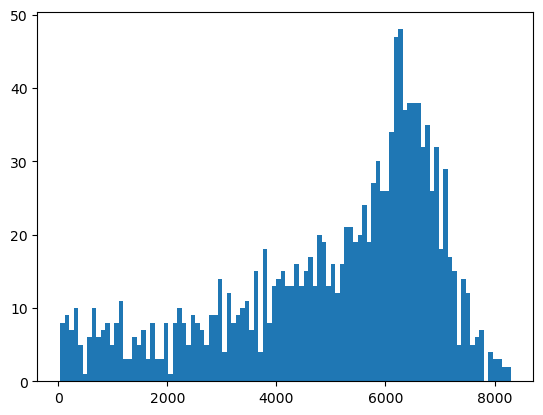

In [52]:
plt.figure()
plt.hist(df.N, 100);

In [53]:
df = df[df['N'] >1000].reset_index(drop=True)

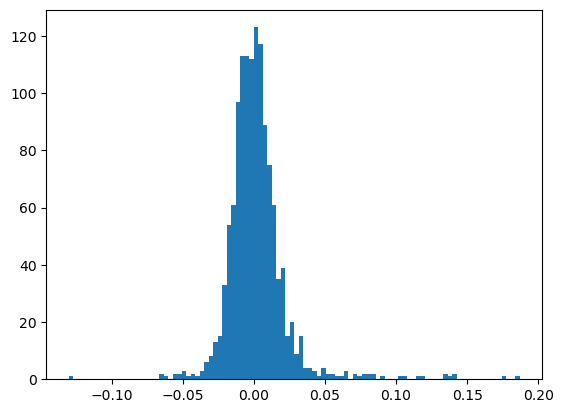

In [55]:
plt.figure()
plt.hist(df['med'], 100);

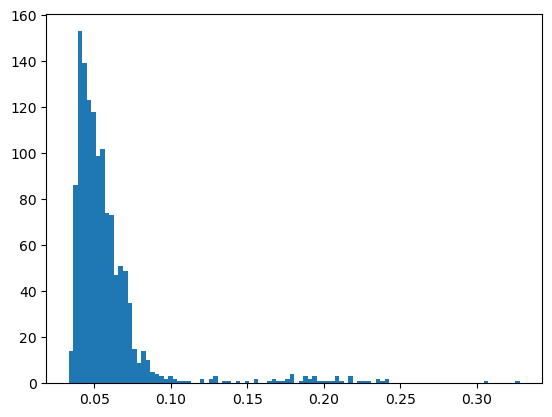

In [56]:
plt.figure()
plt.hist(df['sigma_hat'], 100);

In [64]:
bads = np.array((np.abs(df['med']) > 0.05) | (df['sigma_hat'] > 0.5))

In [65]:
bads

array([False, False, False, ..., False, False, False], shape=(1287,))

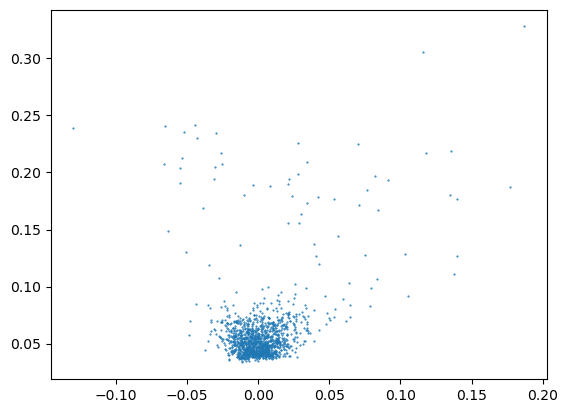

In [58]:
plt.figure()
plt.plot(df['med'], df['sigma_hat'],'.', markersize=1)

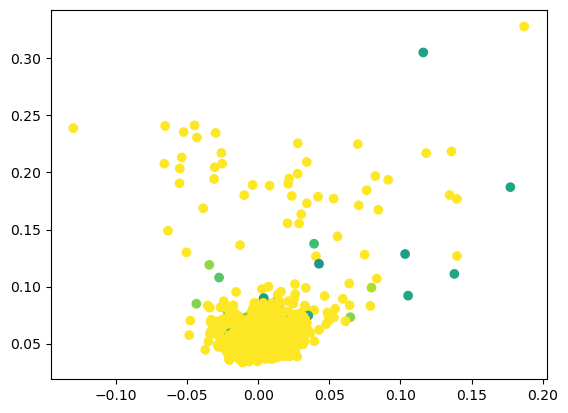

In [60]:
plt.scatter(df['med'], df['sigma_hat'], c=df['N'], clim=[0, 2000])

In [70]:
np.array(df.rgt)[np.flatnonzero(bads)]

array([  57,   99,  101,  102,  117,  178,  186,  218,  239,  261,  280,
        354,  388,  466,  481,  482,  496,  497,  498,  499,  503,  509,
        583,  612,  646,  651,  652,  653,  685,  697,  708,  780,  802,
        849,  971, 1108, 1109, 1150, 1151, 1152])

In [74]:
worst = df.rgt[np.argmax(df.sigma_hat)]

In [75]:
worst

np.int64(497)

In [80]:
! ls /css/icesat-2/ATLAS/ATL06.007/*/*04972811*

/css/icesat-2/ATLAS/ATL06.007/2025.07.18/ATL06_20250718074758_04972811_007_01.h5


In [96]:
D=pc.ATL06.data(beam_pair=2).from_h5('/css/icesat-2/ATLAS/ATL06.007/2025.07.18/ATL06_20250718074758_04972811_007_01.h5')

In [97]:
#D.coordinates=['x','y']
D.get_xy(3031)

<class 'pointCollection.ATL06.data.data'> with shape (108997, 2),
with fields:
['delta_time', 'h_li', 'h_li_sigma', 'latitude', 'longitude', 'atl06_quality_summary', 'segment_id', 'sigma_geo_h', 'x_atc', 'y_atc', 'seg_azimuth', 'sigma_geo_at', 'sigma_geo_xt', 'dh_fit_dx', 'dh_fit_dx_sigma', 'h_mean', 'dh_fit_dy', 'h_rms_misfit', 'h_robust_sprd', 'n_fit_photons', 'signal_selection_source', 'snr_significance', 'w_surface_window_final', 'bsnow_conf', 'bsnow_h', 'cloud_flg_asr', 'cloud_flg_atm', 'r_eff', 'tide_ocean', 'valid', 'BP', 'LR', 'cycle_number', 'rgt', 'x', 'y']

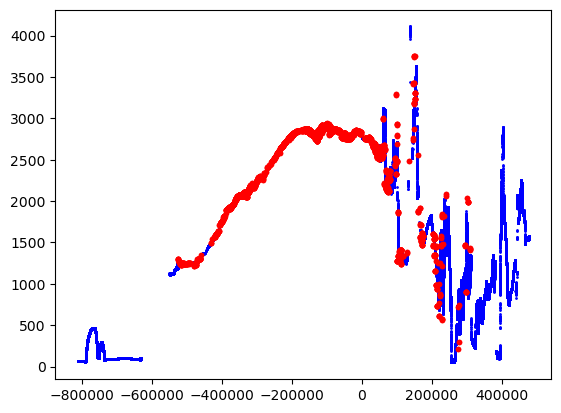

In [99]:
plt.figure()
D.h_li[D.atl06_quality_summary>0]=np.nan
plt.plot(D.x, D.h_li,'b.', markersize=2)
these = np.any(v.rgt==worst, axis=1)
plt.plot(v.x[these], v.h_li[these],'r.')

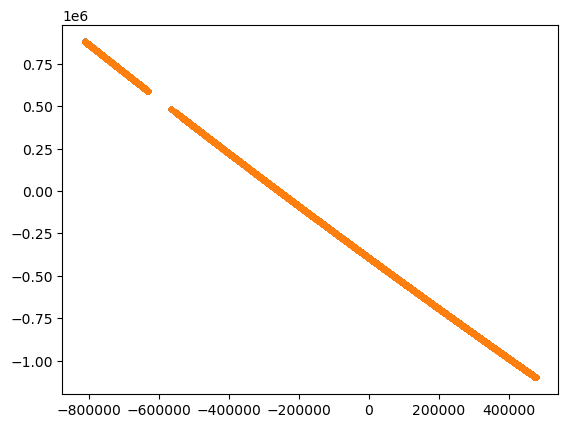

In [94]:
plt.figure()
plt.plot(D.x, D.y,'.')